In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
# Import the Dataset

df = pd.read_csv ('flower2D.csv')
print(df.shape)
print(df.info())
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

(400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  400 non-null    int64  
 1   X1          400 non-null    float64
 2   X2          400 non-null    float64
 3   Y           400 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 12.6 KB
None


,X1,X2,Y
0,0.005257,-0.303586,0
1,0.996098,3.461645,0
2,0.384404,2.392678,0
3,0.951043,3.282709,0
4,0.091932,1.066689,0


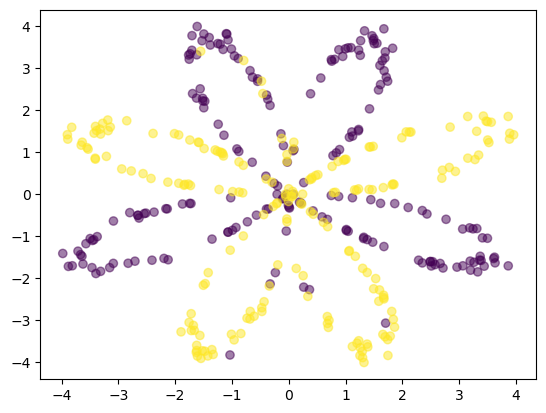

In [3]:
### Visualize the data
plt.scatter(df.X1, df.X2, c=df.Y, alpha=0.5)
plt.show()

### Shuffle the data
df = df.sample(frac=1)

### Preprocess into test and train sets

dataset, testDataset = np.split(df, [int(.7 * len(df))])
X = dataset.drop ('Y' , axis=1)
y = dataset['Y']
XX = testDataset.drop('Y', axis=1)
yy = testDataset['Y']

In [4]:
## Arrange the data into correct matrix form for learning
## Instances are columns instaed of rows

X, y = df[["X1","X2"]], np.array(df["Y"])

m = 300
m_test = X.shape[0] - m
X_train, X_test = X[:m].T, X[m:].T
y_train, y_test = y[:m].reshape(1,m), y[m:].reshape(1,m_test)

In [5]:
X_train

,234,120,162,274,399,266,192,361,232,367,...,223,31,243,214,62,357,301,134,272,319
X1,-0.734874,-1.745954,-0.195759,1.228243,0.679162,3.566114,-0.137890,0.228924,-0.961695,1.676542,...,-1.621045,-0.727910,0.96837,-0.472595,-0.392331,1.813631,1.469809,-1.241895,3.960659,-0.987659
X2,-2.947903,-0.217413,0.196555,0.128343,-2.910063,1.714596,1.439187,-0.234151,-3.464969,-2.490219,...,-3.718928,-0.654659,0.80728,-2.788560,-0.351043,-2.788073,0.108547,1.667258,1.417111,0.063836


In [6]:
y_train

array([[1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
        1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
        0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 

In [7]:

class ReLu:
    # Implement a variable that will store the input during the forward pass
    def __init__(self):
        self.input = None
    # Implement the forward pass of the ReLU
    def forward(self, x):
        self.input = x
        
        return self.input*(self.input>0)

    # Implement the gradient for the backward pass
    def backward(self, gradient_output):
        
        return gradient_output*(self.input>0)


In [8]:
class Sigmoid:
    # Implement a variable that will store the input during the forward pass
    def __init__(self):
        self.input = None
    # Implement the forward pass of the ReLU
    def forward(self, x):
        self.input = x
        s = 1 / (1 + np.exp(-x))
        return s
        

    # Implement the gradient for the backward pass
    def backward(self, gradient_output):
        
        return gradient_output * sigmoid(self.input) * (1 - sigmoid(self.input))


In [9]:
class BatchNorm:
    # Implement a variable that will store the input during the forward pass
    def __init__(self):
        self.input = None
        self.std=None
        self.mean=None

    def forward(self, x):
        self.input = x
        self.std=np.std(self.input,axis=0)
        self.mean=np.mean(self.input,axis=0)
        return (self.input-self.mean)/(self.std+1)#add 1 to avoid division with zero in case std=0

    # Implement the gradient for the backward pass
    def backward(self, gradient_output):
        
        return gradient_output/(self.std+1)#gradients are shrinked, hence exploding gradients can be avoided

In [10]:
def compute_loss(Y, Y_hat):

    m = Y.shape[1]
    L = -(1./m) * ( np.sum( np.multiply(np.log(Y_hat),Y) ) + np.sum( np.multiply(np.log(1-Y_hat),(1-Y)) ) )

    return L

In [11]:
class Linear:
    def __init__(self, input_dim, output_dim):
        self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2. / input_dim) # 'He et al' init strategy
        self.biases = np.zeros((1, output_dim))
        self.input = None
        self.grad_weights = None
        self.grad_biases = None

    def forward(self, x):
        self.input = x
        return np.dot(x, self.weights) + self.biases

    def backward(self, grad_output):
        self.grad_weights = np.dot(self.input.T, grad_output)
        self.grad_biases = np.sum(grad_output, axis=0, keepdims=True)
        return np.dot(grad_output, self.weights.T)

In [12]:
class NeuralNetwork:
    def __init__(self, layers = []):
        #initialising variables
        self.layers = layers
        self.l=1
        self.gradients=None
        self.out=None
        self.parameters=None
    # a simple function that can be used to add 
    def add_layer(self, layer):
        self.layers.append(layer)

    # Implement a function that applies the input x iteratively to each layer and return the final output
    def forward(self, x):
        self.out=x
        for layer in self.layers:
          
            self.out=layer.forward(self.out)
        return self.out

    # Implement a function that iteratively backpropagate the gradients. Remember to start from the last layer.
    def backward(self, gradient_output):
        self.l=gradient_output
        self.parameters=[]
        self.gradients=[]
        
        for layer in self.layers[::-1]:
            self.l = layer.backward(self.l)#backpropagation of gradient
            if isinstance(layer, Linear):
                #store weights and gradients for linear layers
                self.gradients.append([layer.grad_weights,layer.grad_biases])
                self.parameters.append([layer.weights,layer.biases])
        return self.l
    
    # implement a function that returns all the parameters for each layer (both weights and biases) and the gradients
    def parameters_and_gradients(self):
                        
        return self.gradients,self.parameters

In [13]:
def sigmoid(z):
    s = 1 / (1 + np.exp(-z))
    return s

In [14]:
def derivative_binary_classification(preds, labels):
    return preds - labels

In [15]:
def sgd(parameters,gradients, learning_rate):
    for i in range(len(gradients)):
        for j in range(len(parameters[0])):
            parameters[i][j]= parameters[i][j]-learning_rate*gradients[i][j]
    return parameters

In [16]:
def train(network, X_train, Y_train, batch_size, epochs, learning_rate):
    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size
            
    losses=[]            
    for epoch in range(epochs):
        # shuffle data on each epoch
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_train_shuffled = X_train[indices]
        Y_train_shuffled = Y_train[indices]
        loss=0
        # a guarded batching loop is provided for your convenience
        for i in range(n_batches):
            start = i * batch_size
            end = start + batch_size
            end = min(end,n_samples)

            X_batch = X_train_shuffled[start:end]
            Y_batch = Y_train_shuffled[start:end]
        
         # Implement the necessary missing operations:
            
       
            # - Predict classes for the batch of observations (remember to use softmax on the NN output)
            output=network.forward(X_batch)
            output=sigmoid(output)
           
            # - Compute the loss between predictions and true lables
            loss+=compute_loss(Y_batch,output)
            if np.isnan(loss):
                break
            
            gradient=derivative_binary_classification(output,Y_batch)
            # - Backpropagate the gradients thoughout the network
            network.backward(gradient)
            #getting gradients and parameters from neural network
            gradients,parameters=network.parameters_and_gradients()
            # - Use the gradient descent function to update the parameters 
            parameters=sgd(parameters,gradients, learning_rate)
            
            #iteratively updating the new parameters after the gradient descent
            i=0
            for obj in network.layers[::-1]:
                if isinstance(obj, Linear):
                    obj.weights=parameters[i][0]
                    obj.biases=parameters[i][1]
                    i+=1
        #average loss per batch
        loss=loss/n_batches
        losses.append(loss)        
        
        print(f"Epoch {epoch+1}, Loss: {loss}")
    return losses

In [17]:
losses=[]

### Task1


In [18]:
X_train=np.asarray(np.transpose(X_train))


In [19]:
y_train=np.transpose(y_train)


In [20]:
X_test=np.asarray(np.transpose(X_test))

In [21]:
y_test=np.transpose(y_test)

In [22]:
batch_size = 300
epochs = 500
learning_rate = 0.01

In [23]:
n1=NeuralNetwork(layers=[Linear(2,10),ReLu()])
n1.add_layer(BatchNorm())
n1.add_layer(Linear(10,1))

In [24]:
losses.append(train(n1, X_train,y_train, batch_size, epochs, learning_rate))

Epoch 1, Loss: 261.1655634205083
Epoch 2, Loss: 209.55485512436513
Epoch 3, Loss: 202.58106943586313
Epoch 4, Loss: 199.96388278040808
Epoch 5, Loss: 198.5491256136974
Epoch 6, Loss: 197.72954978832175
Epoch 7, Loss: 197.31264626804153
Epoch 8, Loss: 197.0265358625977
Epoch 9, Loss: 196.78311608887813
Epoch 10, Loss: 196.54170376359139
Epoch 11, Loss: 196.29762030449228
Epoch 12, Loss: 196.04947841169155
Epoch 13, Loss: 195.78140335552035
Epoch 14, Loss: 195.49618806391948
Epoch 15, Loss: 195.25754486200094
Epoch 16, Loss: 194.95450576409905
Epoch 17, Loss: 194.58266646342463
Epoch 18, Loss: 194.22869713052467
Epoch 19, Loss: 193.84942465227482
Epoch 20, Loss: 193.4831850641258
Epoch 21, Loss: 193.0740813130767
Epoch 22, Loss: 192.50093483040985
Epoch 23, Loss: 191.975892368536
Epoch 24, Loss: 191.45214891251135
Epoch 25, Loss: 190.99421820037037
Epoch 26, Loss: 190.42899170434595
Epoch 27, Loss: 189.75218620727395
Epoch 28, Loss: 189.21171150106528
Epoch 29, Loss: 188.51804950361822
E

In [25]:
output=n1.forward(X_train)
output=sigmoid(output)
predict=np.where(output > 0.5, 1, 0)


In [26]:
print('Training Accuracy is {}'.format(np.mean(predict==y_train)))

Training Accuracy is 0.8666666666666667


In [27]:
output=sigmoid(n1.forward(X_test))

In [28]:
predict=np.where(output > 0.5, 1, 0)

In [29]:
print('Testing Accuracy is {}'.format(np.mean(predict==y_test)))

Testing Accuracy is 0.87


In [30]:
from itertools import product
points = np.array(list(product(range(-450,450),range(-450,450))))
mypoints = points*0.01

bdpreds =np.where(sigmoid(n1.forward(mypoints ))>0.5,1,0)


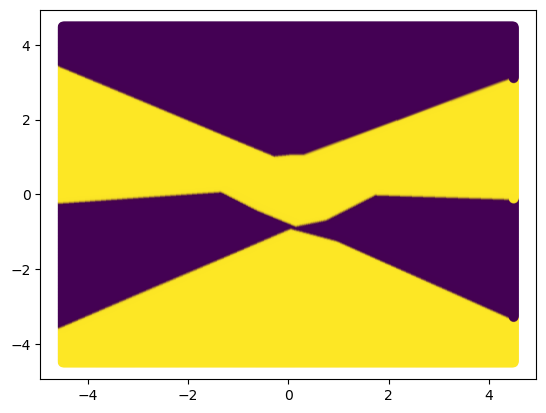

In [31]:
plt.scatter(mypoints[:,0],mypoints[:,1], c=bdpreds, alpha=0.5)
plt.show()

### Task2

In [32]:
batch_size = 300
epochs = 500
learning_rate = 0.01

In [33]:
n2=NeuralNetwork(layers=[Linear(2,30),ReLu()])
n2.add_layer(BatchNorm())
n2.add_layer(Linear(30,5))
n2.add_layer(ReLu())
n2.add_layer(BatchNorm())
n2.add_layer(Linear(5,1))

In [34]:
losses.append(train(n2, X_train,y_train, batch_size, epochs, learning_rate))

Epoch 1, Loss: 245.58593041356417
Epoch 2, Loss: 207.22575192215723
Epoch 3, Loss: 205.1791142751693
Epoch 4, Loss: 204.1836231690922
Epoch 5, Loss: 202.20691934427708
Epoch 6, Loss: 200.0336143183718
Epoch 7, Loss: 195.60199729170662
Epoch 8, Loss: 190.6707145608155
Epoch 9, Loss: 184.86463616568034
Epoch 10, Loss: 180.1692746471575
Epoch 11, Loss: 174.98108264917968
Epoch 12, Loss: 169.7427114081298
Epoch 13, Loss: 164.40118465331665
Epoch 14, Loss: 159.16335571946775
Epoch 15, Loss: 154.2824810942771
Epoch 16, Loss: 149.49010374815944
Epoch 17, Loss: 145.280040063885
Epoch 18, Loss: 141.46138947924018
Epoch 19, Loss: 138.06643438853763
Epoch 20, Loss: 135.04378092213685
Epoch 21, Loss: 132.50454639164747
Epoch 22, Loss: 130.04250993272956
Epoch 23, Loss: 128.0333419875472
Epoch 24, Loss: 125.6789692658527
Epoch 25, Loss: 123.84748332163164
Epoch 26, Loss: 122.13468182464942
Epoch 27, Loss: 120.53461177056963
Epoch 28, Loss: 118.87027176181066
Epoch 29, Loss: 117.33128769975227
Epoch

In [35]:
output=n2.forward(X_train)
output=sigmoid(output)
predict=np.where(output > 0.5, 1, 0)


In [36]:
print('Training Accuracy is {}'.format(np.mean(predict==y_train)))

Training Accuracy is 0.91


In [37]:
output=sigmoid(n2.forward(X_test))

In [38]:
predict=np.where(output > 0.5, 1, 0)

In [39]:
print('Testing Accuracy is {}'.format(np.mean(predict==y_test)))

Testing Accuracy is 0.87


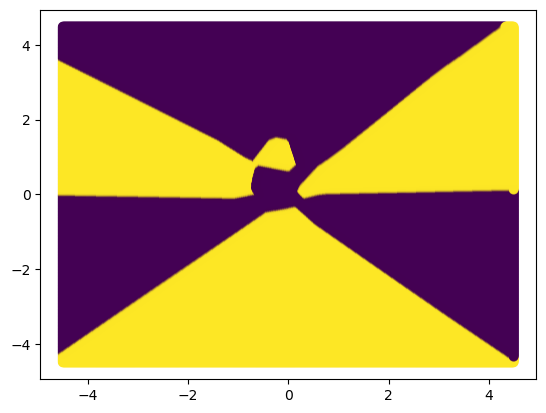

In [40]:
bdpreds =np.where(sigmoid(n2.forward(mypoints ))>0.5,1,0)

plt.scatter(mypoints[:,0],mypoints[:,1], c=bdpreds, alpha=0.5)
plt.show()

### Task3

In [41]:
batch_size = 300
epochs = 500
learning_rate = 0.01

In [42]:
n3=NeuralNetwork(layers=[Linear(2,20),ReLu()])
n3.add_layer(BatchNorm())
n3.add_layer(Linear(20,12))
n3.add_layer(ReLu())
n3.add_layer(BatchNorm())
n3.add_layer(Linear(12,6))
n3.add_layer(ReLu())
n3.add_layer(BatchNorm())
n3.add_layer(Linear(6,1))

In [43]:
losses.append(train(n3, X_train,y_train, batch_size, epochs, learning_rate))

Epoch 1, Loss: 209.44259949355612
Epoch 2, Loss: 186.62987826997085
Epoch 3, Loss: 177.65099062924068
Epoch 4, Loss: 167.69000945469222
Epoch 5, Loss: 158.0586987836926
Epoch 6, Loss: 147.9207787558796
Epoch 7, Loss: 138.80514583543098
Epoch 8, Loss: 130.41367423331303
Epoch 9, Loss: 123.32208298073326
Epoch 10, Loss: 117.573165879471
Epoch 11, Loss: 112.60406468696338
Epoch 12, Loss: 108.8285903922042
Epoch 13, Loss: 105.91750101342112
Epoch 14, Loss: 103.50188170541902
Epoch 15, Loss: 101.44811784097949
Epoch 16, Loss: 99.73006188514535
Epoch 17, Loss: 98.14721049573032
Epoch 18, Loss: 96.97403908851852
Epoch 19, Loss: 95.63127252907638
Epoch 20, Loss: 94.42591592390248
Epoch 21, Loss: 93.32903346591804
Epoch 22, Loss: 92.38004527234472
Epoch 23, Loss: 91.5389645773991
Epoch 24, Loss: 90.8416475396536
Epoch 25, Loss: 90.16315833832314
Epoch 26, Loss: 89.32667292240595
Epoch 27, Loss: 88.62496579133952
Epoch 28, Loss: 87.96546174741096
Epoch 29, Loss: 87.36694247979179
Epoch 30, Loss:

In [44]:
output=n3.forward(X_train)
output=sigmoid(output)
predict=np.where(output > 0.5, 1, 0)


In [45]:
print('Training Accuracy is {}'.format(np.mean(predict==y_train)))

Training Accuracy is 0.9166666666666666


In [46]:
output=sigmoid(n3.forward(X_test))

In [47]:
predict=np.where(output > 0.5, 1, 0)

In [48]:
print('Testing Accuracy is {}'.format(np.mean(predict==y_test)))

Testing Accuracy is 0.85


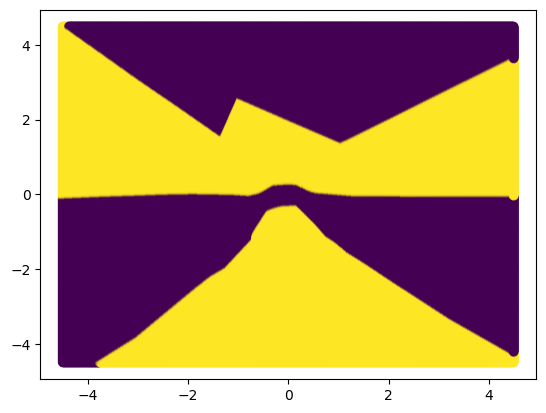

In [49]:
bdpreds =np.where(sigmoid(n3.forward(mypoints ))>0.5,1,0)

plt.scatter(mypoints[:,0],mypoints[:,1], c=bdpreds, alpha=0.5)
plt.show()

### Task 4

In [50]:
n4=NeuralNetwork(layers=[Linear(2,20),ReLu()])
n4.add_layer(BatchNorm())
n4.add_layer(Linear(20,15))
n4.add_layer(ReLu())
n4.add_layer(BatchNorm())
n4.add_layer(Linear(15,10))
n4.add_layer(ReLu())
n4.add_layer(BatchNorm())
n4.add_layer(Linear(10,5))
n4.add_layer(ReLu())
n4.add_layer(BatchNorm())
n4.add_layer(Linear(5,1))

In [51]:
losses.append(train(n4, X_train,y_train, batch_size, epochs, learning_rate))

Epoch 1, Loss: 210.5150720986351
Epoch 2, Loss: 198.29367129567413
Epoch 3, Loss: 189.9761356114876
Epoch 4, Loss: 181.7763829515932
Epoch 5, Loss: 171.68336202816812
Epoch 6, Loss: 159.2684002639386
Epoch 7, Loss: 147.82899880571483
Epoch 8, Loss: 139.08769810513053
Epoch 9, Loss: 134.30286614373722
Epoch 10, Loss: 129.52206481746686
Epoch 11, Loss: 128.43586510422915
Epoch 12, Loss: 119.4167757997216
Epoch 13, Loss: 113.36200909511264
Epoch 14, Loss: 108.79060199422818
Epoch 15, Loss: 105.0681941809593
Epoch 16, Loss: 102.49514451940829
Epoch 17, Loss: 99.966493758009
Epoch 18, Loss: 98.22358849384946
Epoch 19, Loss: 96.31545965832133
Epoch 20, Loss: 94.87872795230228
Epoch 21, Loss: 93.39241726837506
Epoch 22, Loss: 92.29933924280542
Epoch 23, Loss: 91.23776147847082
Epoch 24, Loss: 91.12567715316165
Epoch 25, Loss: 91.53248739928901
Epoch 26, Loss: 90.85961900999571
Epoch 27, Loss: 90.41794149505648
Epoch 28, Loss: 89.39122734605203
Epoch 29, Loss: 88.5367965467482
Epoch 30, Loss: 

In [52]:
output=n4.forward(X_train)
output=sigmoid(output)
predict=np.where(output > 0.5, 1, 0)


In [53]:
print('Training Accuracy is {}'.format(np.mean(predict==y_train)))

Training Accuracy is 0.9233333333333333


In [54]:
output=sigmoid(n4.forward(X_test))

In [55]:
predict=np.where(output > 0.5, 1, 0)

In [56]:
print('Testing Accuracy is {}'.format(np.mean(predict==y_test)))

Testing Accuracy is 0.86


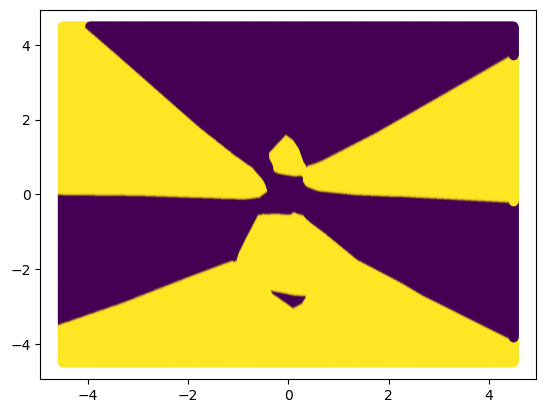

In [57]:
bdpreds =np.where(sigmoid(n4.forward(mypoints ))>0.5,1,0)

plt.scatter(mypoints[:,0],mypoints[:,1], c=bdpreds, alpha=0.5)
plt.show()

### Task 5

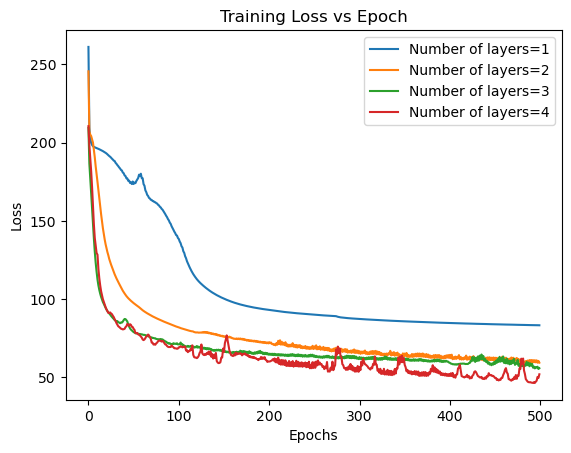

In [58]:
plt.figure()
for i in range(len(losses)):
    plt.plot(losses[i])
plt.xlabel("Epochs")
plt.ylabel("Loss")
# plt.ylim(10, 21)
plt.title('Training Loss vs Epoch')
plt.legend(['Number of layers=1', 'Number of layers=2','Number of layers=3','Number of layers=4'])
plt.show()

In [59]:
networks=[n1,n2,n3,n4]
accuracy_train=[]
accuracy_test=[]
for i in range(len(networks)):
    output=sigmoid(networks[i].forward(X_train))
    predict=np.where(output > 0.5, 1, 0)
    accuracy_train.append(np.mean(predict==y_train))
    output=sigmoid(networks[i].forward(X_test))
    predict=np.where(output > 0.5, 1, 0)
    accuracy_test.append(np.mean(predict==y_test))

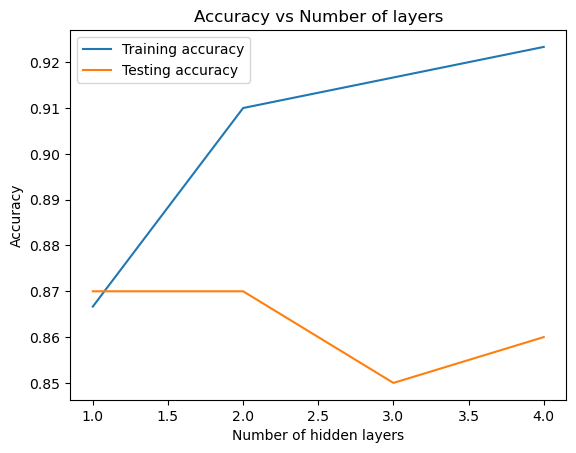

In [60]:
plt.figure()
layers=[1,2,3,4]
plt.plot(layers,accuracy_train)
plt.plot(layers,accuracy_test)
plt.xlabel("Number of hidden layers")
plt.ylabel("Accuracy")
plt.legend(['Training accuracy', 'Testing accuracy'])
plt.title('Accuracy vs Number of layers')
plt.show()

In [61]:
def confusion_matrix_(prediction_data,actual_data):
    cm=confusion_matrix(actual_data,prediction_data)
    cmDF = pd.DataFrame(cm)
    cmDF.index.name = 'Actual'
    cmDF.columns.name = 'Predicted'
    print("Confusion Matrix:")
    print(cmDF)
    print('-'*100)

In [62]:
def evaluation_metrics(label_output,label_probabilities,label_predictions):
    fpr, tpr, _ = roc_curve(label_output, label_probabilities)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.plot(fpr,tpr)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.show()  
    print("AUC of validation set : ",'{:.2%}'.format(roc_auc_score(label_output, label_probabilities)))
    tn, fp, fn, tp = confusion_matrix(label_output,label_predictions).ravel()
    print("Positive Predictive Value: ",'{:.2%}'.format(tp/(tp+fp)))





Confusion matrix of training data for n1 neural network

Confusion Matrix:
Predicted    0    1
Actual             
0          123   25
1           15  137
----------------------------------------------------------------------------------------------------
Confusion matrix of test data for n1 neural network

Confusion Matrix:
Predicted   0   1
Actual           
0          44   8
1           5  43
----------------------------------------------------------------------------------------------------
Evaluation metrics for for n1 neural network



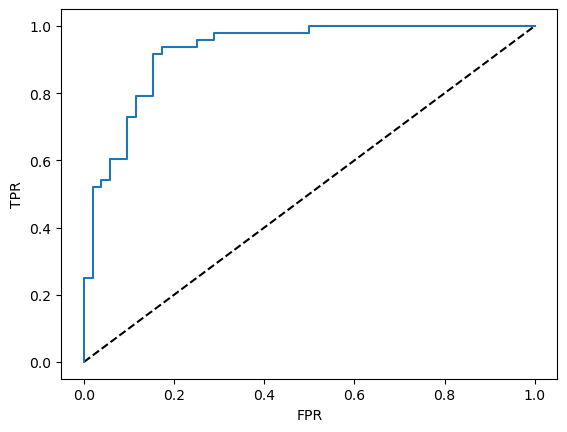

AUC of validation set :  92.67%
Positive Predictive Value:  84.31%




Confusion matrix of training data for n2 neural network

Confusion Matrix:
Predicted    0    1
Actual             
0          134   14
1           13  139
----------------------------------------------------------------------------------------------------
Confusion matrix of test data for n2 neural network

Confusion Matrix:
Predicted   0   1
Actual           
0          42  10
1           3  45
----------------------------------------------------------------------------------------------------
Evaluation metrics for for n2 neural network



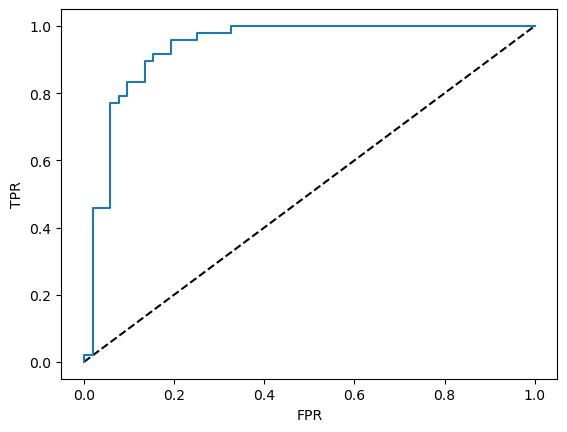

AUC of validation set :  93.63%
Positive Predictive Value:  81.82%




Confusion matrix of training data for n3 neural network

Confusion Matrix:
Predicted    0    1
Actual             
0          140    8
1           17  135
----------------------------------------------------------------------------------------------------
Confusion matrix of test data for n3 neural network

Confusion Matrix:
Predicted   0   1
Actual           
0          44   8
1           7  41
----------------------------------------------------------------------------------------------------
Evaluation metrics for for n3 neural network



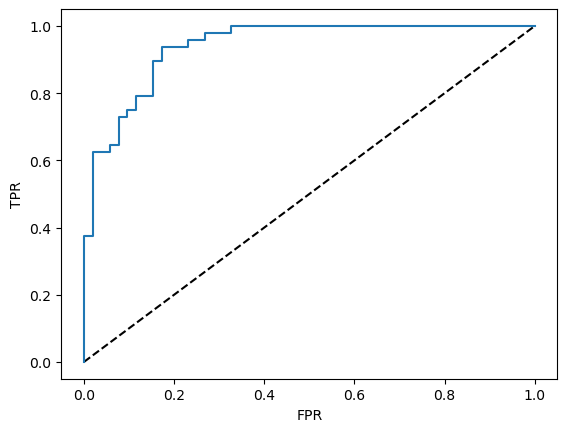

AUC of validation set :  94.03%
Positive Predictive Value:  83.67%




Confusion matrix of training data for n4 neural network

Confusion Matrix:
Predicted    0    1
Actual             
0          130   18
1            5  147
----------------------------------------------------------------------------------------------------
Confusion matrix of test data for n4 neural network

Confusion Matrix:
Predicted   0   1
Actual           
0          43   9
1           5  43
----------------------------------------------------------------------------------------------------
Evaluation metrics for for n4 neural network



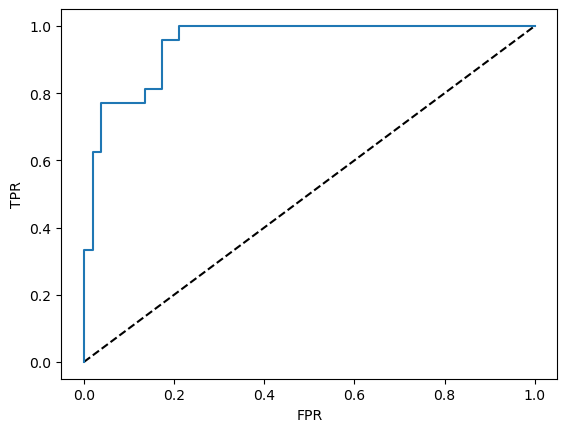

AUC of validation set :  94.91%
Positive Predictive Value:  82.69%


In [63]:
from sklearn.metrics import *
for i in range(len(networks)):
    output=sigmoid(networks[i].forward(X_train))
    predict=np.where(output > 0.5, 1, 0)
    print("\n\n\n\nConfusion matrix of training data for n{} neural network\n".format(i+1))
    confusion_matrix_(predict,y_train)
    output=sigmoid(networks[i].forward(X_test))
    predict=np.where(output > 0.5, 1, 0)
    print("Confusion matrix of test data for n{} neural network\n".format(i+1))
    confusion_matrix_(predict,y_test)
    print("Evaluation metrics for for n{} neural network\n".format(i+1))
    evaluation_metrics(y_test,output,predict)